# EXPLORATORY DATA ANALYSIS ON A DATASET

<b>1.	Data Cleaning and Preparation:</b>

In [1]:
import pandas as pd
cardiotocographic = pd.read_csv("C:/Users/shanm/Python_Practice/Datasets/Cardiotocographic.csv")
data = cardiotocographic.head()
data

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [2]:
# Finding no of null values in a column
cardiotocographic.isna().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [3]:
# Finding average value to replace null

LB_avg = cardiotocographic['LB'].mean()
print("LB_avg : ",LB_avg)

AC_avg = cardiotocographic['AC'].mean()
print("AC_avg : ",AC_avg)

DS_avg = cardiotocographic['DS'].mean()
print("DS_avg : ",DS_avg)

DP_avg = cardiotocographic['DP'].mean()
print("DP_avg : ",DP_avg)

MLTV_avg = cardiotocographic['MLTV'].mean()
print("MLTV_avg : ",MLTV_avg)

Width_avg = cardiotocographic['Width'].mean()
print("Width_avg : ",Width_avg)

Tendency_avg = cardiotocographic['Tendency'].mean()
print("Tendency_avg : ",Tendency_avg)

NSP_avg = cardiotocographic['NSP'].mean()
print("NSP_avg : ",NSP_avg)

LB_avg :  133.3435983550352
AC_avg :  0.0032189782438000465
DS_avg :  2.5089835057102827e-06
DP_avg :  0.00017515121174634704
MLTV_avg :  8.28488742706321
Width_avg :  70.42926049411918
Tendency_avg :  0.3163714038702473
NSP_avg :  1.304507175110962


In [4]:
# Replacing null with appropriate value

import numpy as np
cardiotocographic.fillna({
    'LB' : LB_avg,
    'AC' : AC_avg,
    'DS' : DS_avg,
    'DP' : DP_avg,
    'MLTV' : MLTV_avg,
    'Width' : Width_avg,
    'Tendency' : Tendency_avg,
    'NSP' : NSP_avg
},inplace=True
)
cardiotocographic.isna().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [5]:
# Checking for any inconsistencies in data types
print(cardiotocographic.dtypes)

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


#### All columns belongs to number datatype

In [6]:
# Detecting outliers
import matplotlib.pyplot as plt
cardiotocographic.describe()


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.214328,0.004370,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734356,42.719161,0.642424,0.641426
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001668,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


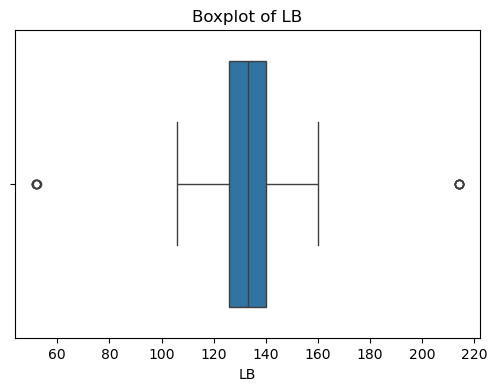

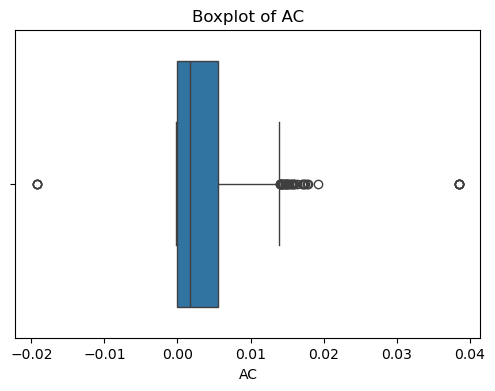

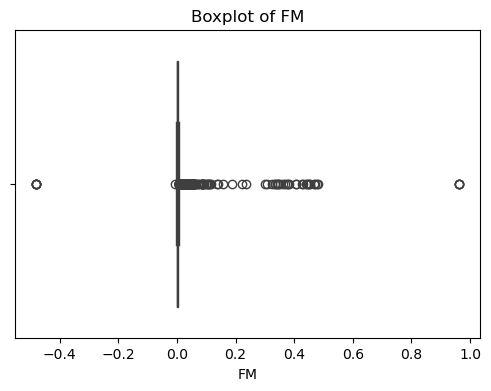

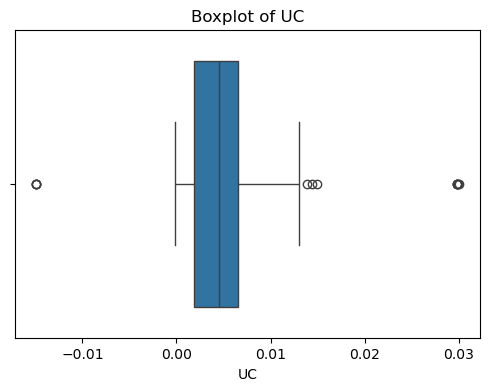

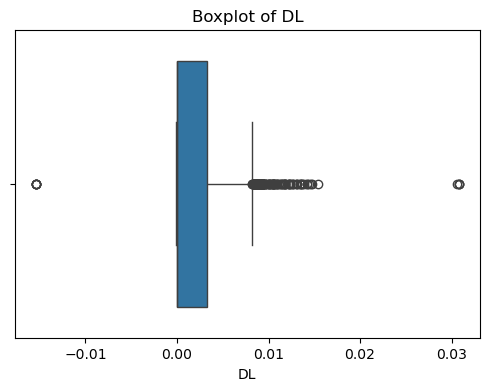

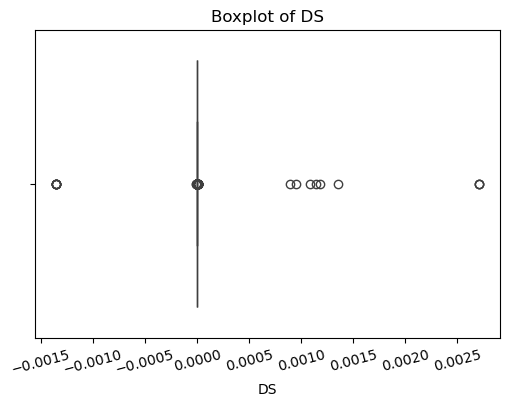

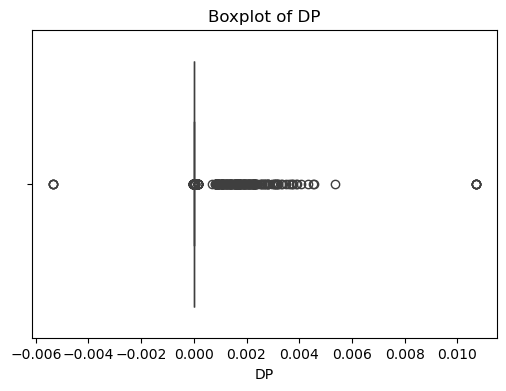

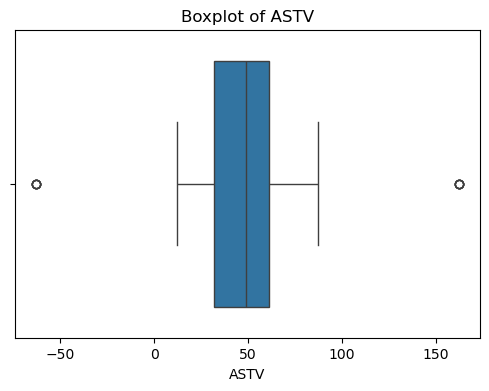

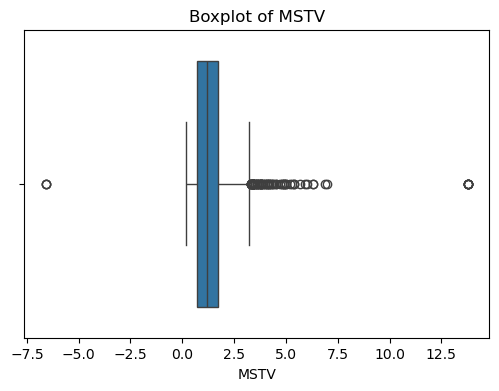

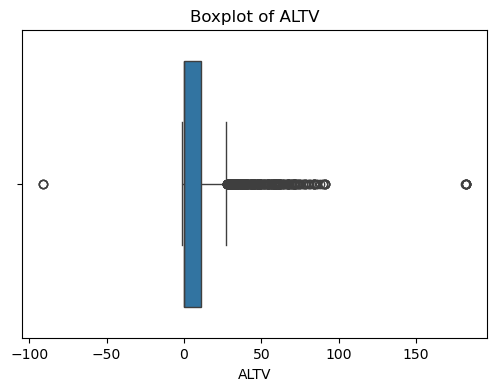

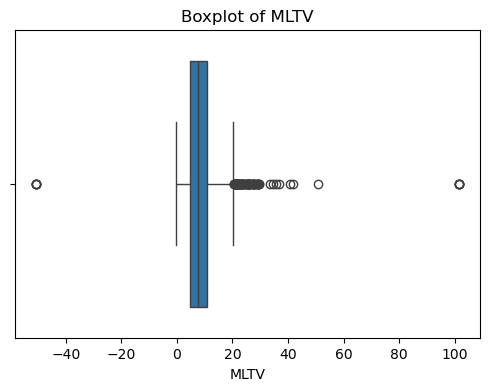

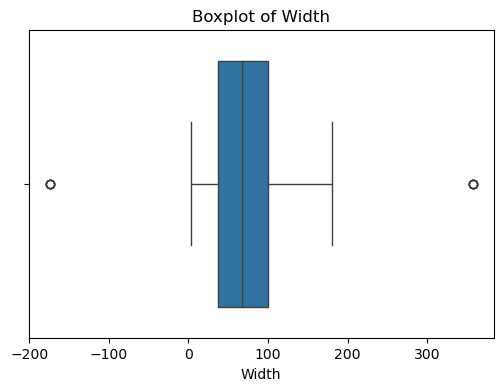

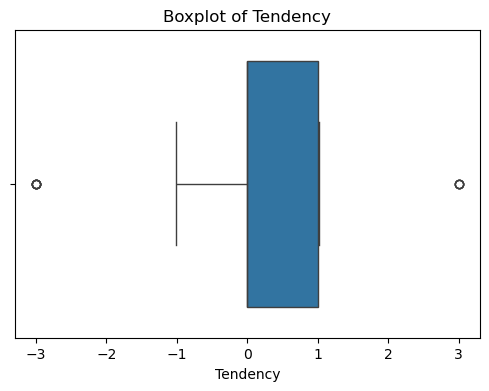

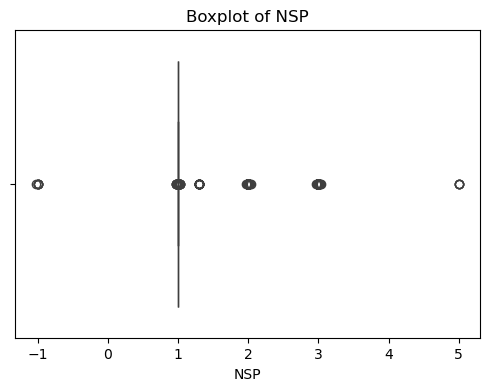

In [7]:
# Plotting Box plots to find Outliers

import seaborn as sns
for i in cardiotocographic.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=cardiotocographic[i])
    if i=="DS":
        plt.xticks(rotation=15)
    plt.title(f"Boxplot of {i}")
    plt.show()



## Insights :</br>
-- There are not much outliers in LB meaning that "Baseline Fetal Heart Rate (FHR)" is mostly stable</br>
-- Ouliers exist at right end of AC meaning Accelerations are right skewed and high accerlations can be seemed in some report and high accerlations denote fetal well-being.</br>
-- Ouliers exist at right end of FM meaning fetal movements are right skewed and between 0 to 0.8<br/>
-- There aren't much outliers for UC meaning that there is a stable healthy uterine contractions<br/>
-- DL is also right skewed, which means there are some abnormal DL rate. <br/>
-- DS has outliers in its right, it range between 0.0005 and 0.0025.DS <30 seconds is considered normal<br/>
-- DP has outliers but DP < 2 minutes is considered safe<br/>
-- Data in ASTV is stable without much outliers<br/>
-- Outliers exist in right end of MSTV.Typically > 6 ms is considered reassuring.- < 3 ms is often associated with fetal hypoxia or acidosi
<br
-- MLTV more than 25 bpm is considered abnormal and data showing more records with abnormal MLTV/>

In [8]:
cardiotocographic.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

In [9]:
# Treating Outliers

def wisker(col):
    q1,q3 = np.percentile(cardiotocographic[i],[25,75])
    iqr = q3-q1
    lw = q1-(1.5)*iqr
    uw = q3+(1.5)*iqr
    return lw,uw

for i in ['LB', 'AC', 'FM', 'UC', 'DL','ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency']:
    lw,uw = wisker(cardiotocographic[i])
    cardiotocographic[i] = np.where(cardiotocographic[i]<lw,lw,cardiotocographic[i])
    cardiotocographic[i] = np.where(cardiotocographic[i]>uw,uw,cardiotocographic[i])

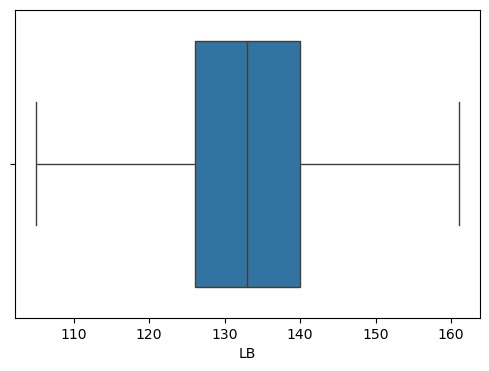

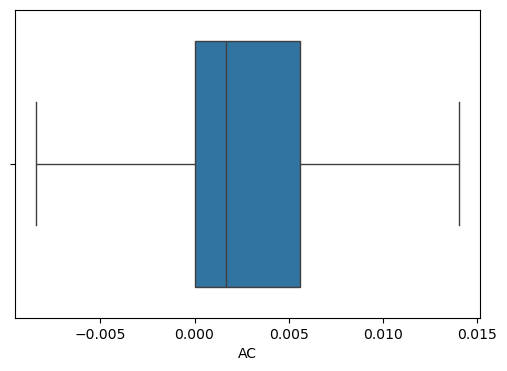

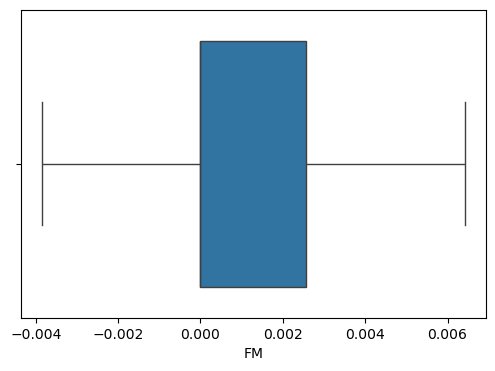

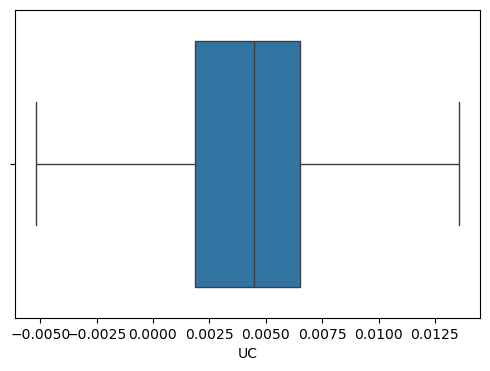

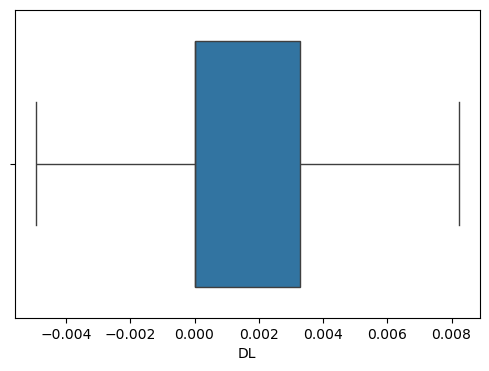

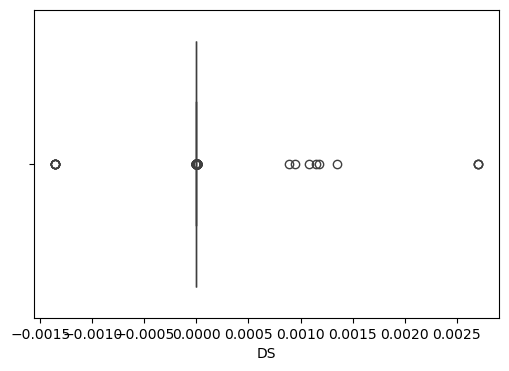

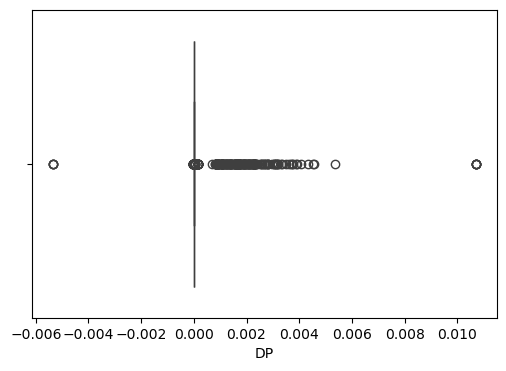

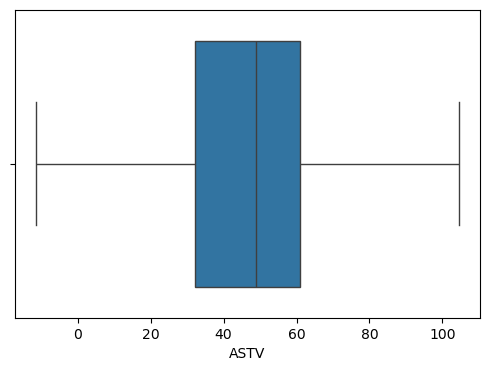

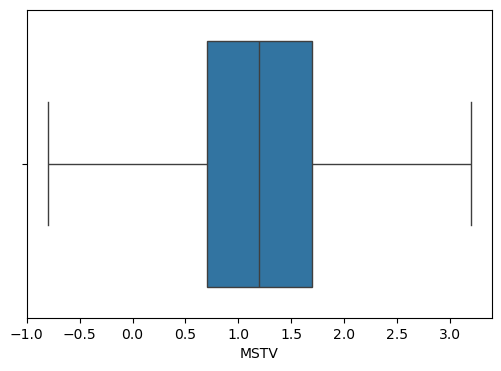

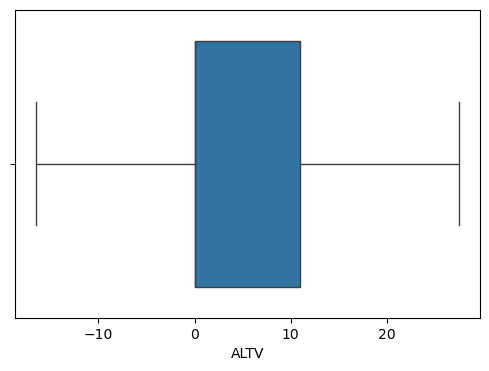

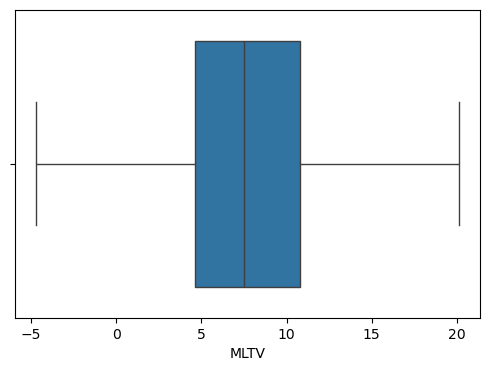

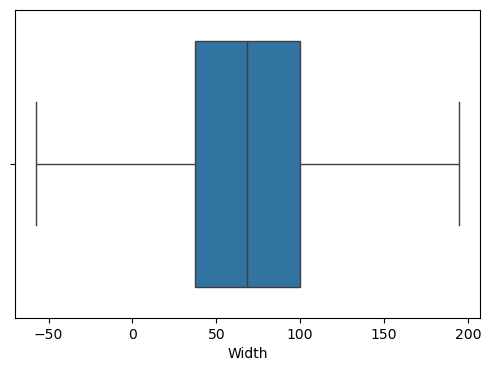

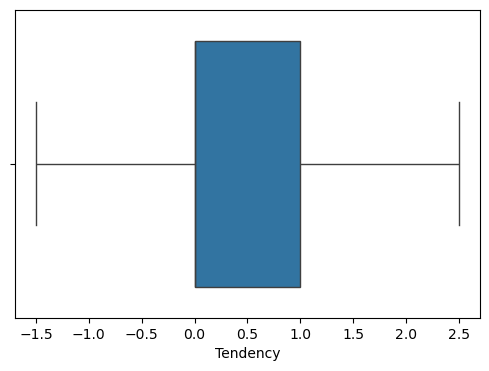

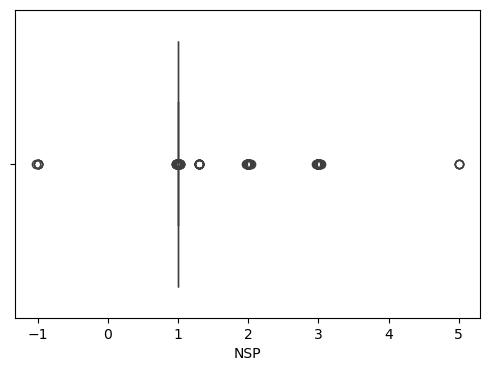

In [10]:
# Lets check for the outliers now using box plot

for i in cardiotocographic.select_dtypes(include="number").columns:
    plt.figure(figsize=[6,4])
    sns.boxplot(x=cardiotocographic[i])
    plt.show()

## 2.	Statistical Summary:

In [11]:
cardiotocographic.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.293725,0.003147,0.001568,0.004362,0.001770,0.000003,0.000175,46.981873,1.304644,6.691678,8.016212,70.321076,0.319662,1.304507
std,9.930227,0.003826,0.002485,0.003001,0.002668,0.000141,0.000836,17.612745,0.781091,10.378400,5.046784,39.570633,0.621602,0.641426
min,105.000000,-0.008409,-0.003850,-0.005177,-0.004934,-0.001353,-0.005348,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001668,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,161.000000,0.014015,0.006416,0.013564,0.008224,0.002706,0.010695,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,5.000000


Insights:-

-- Several variables (FM, ALTV, Width, ASTV, MLTV) show extreme outliers.</br>
-- Some features (DS, DP, DL) are almost always zero, indicating possible sparsity.</br>
-- NSP is categorical data where it says Normal, suspect or pathologic


## 3.	Data Visualization:

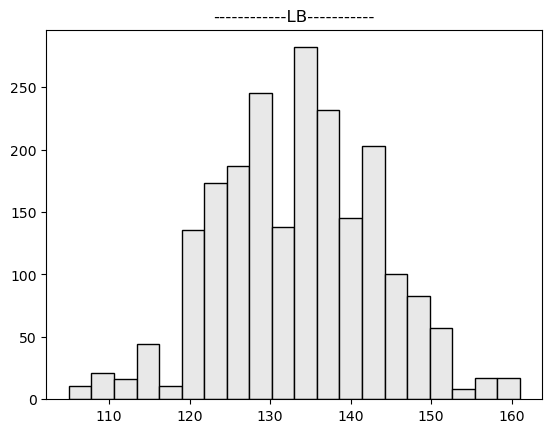

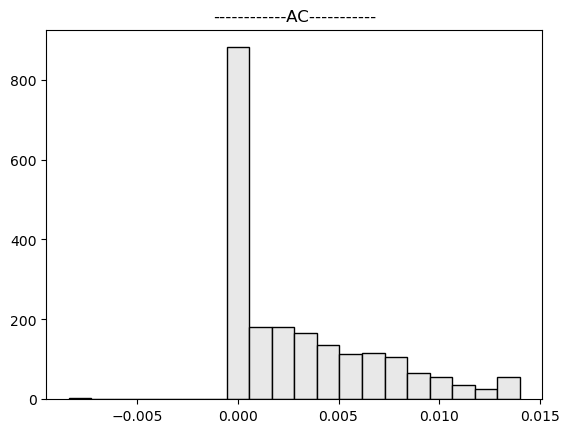

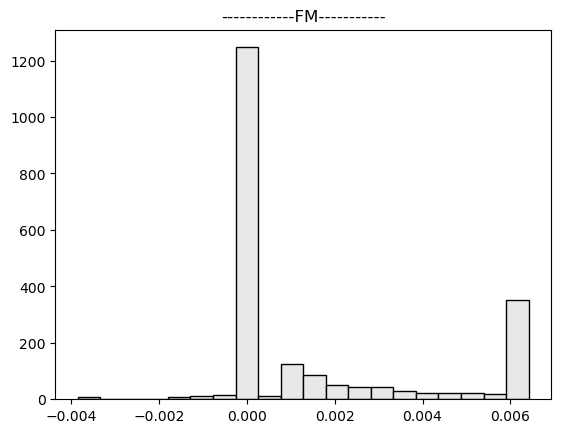

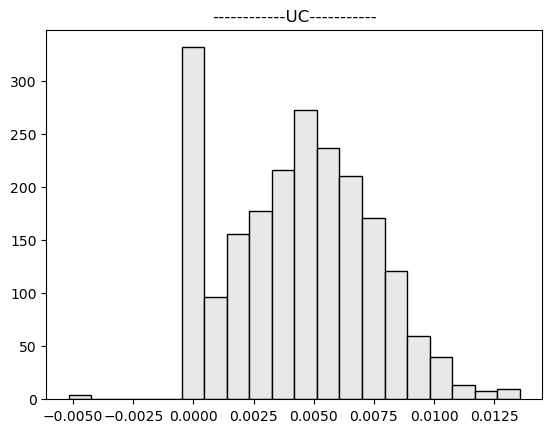

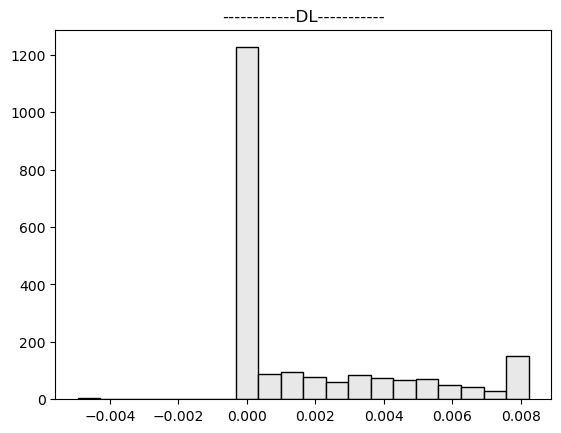

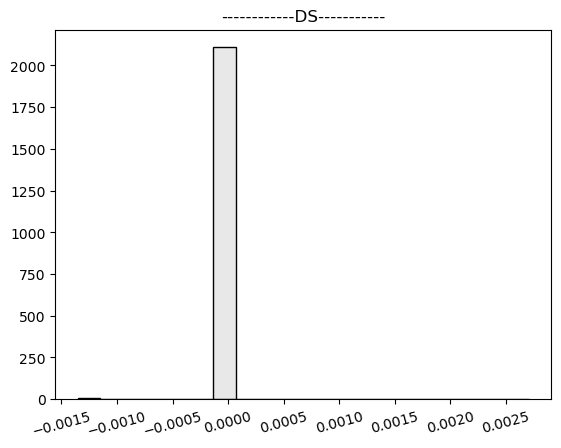

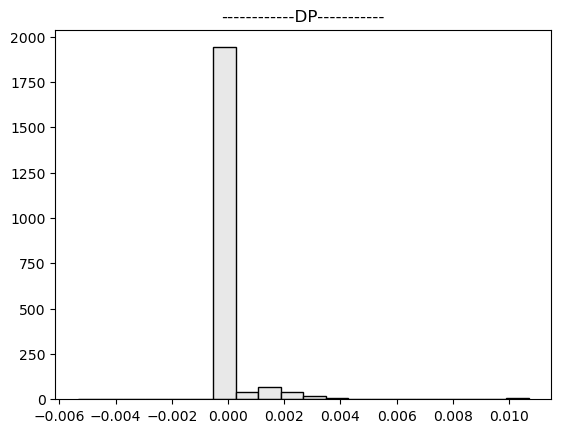

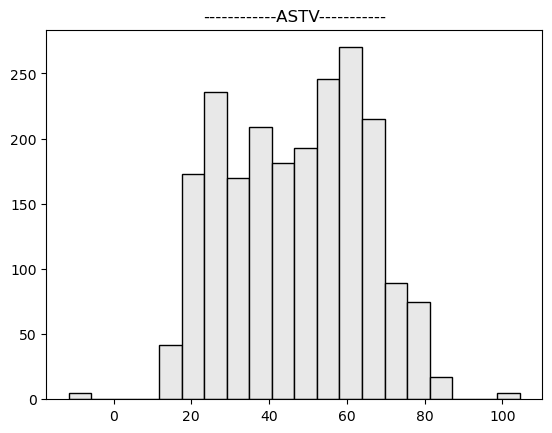

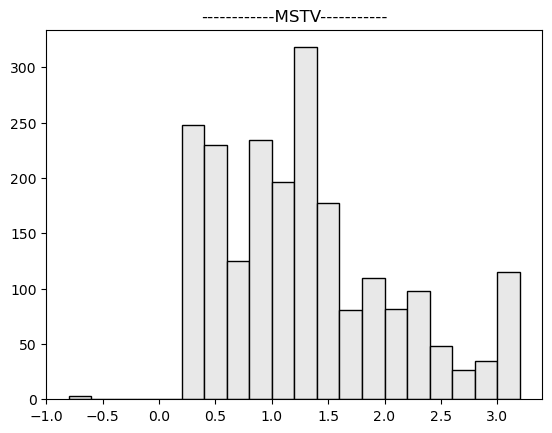

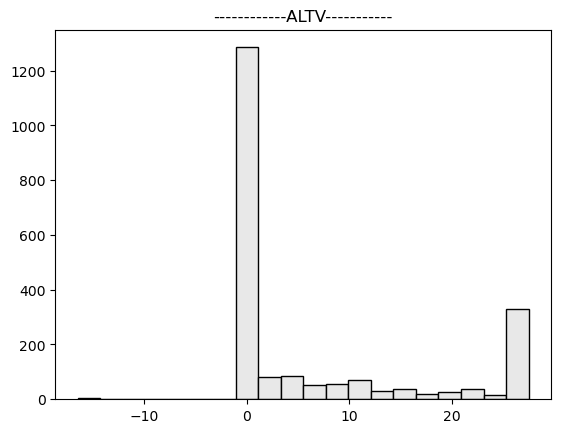

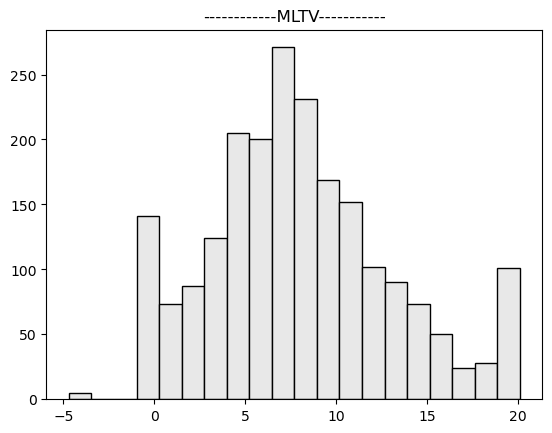

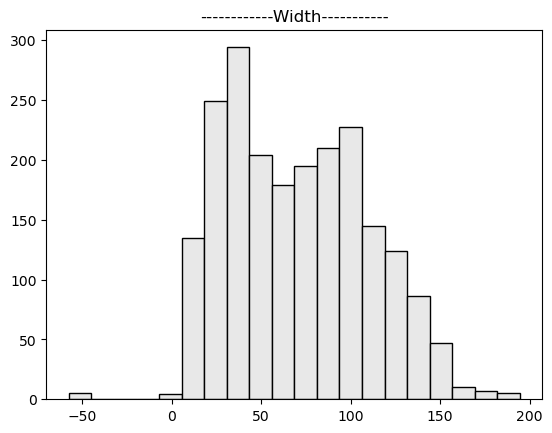

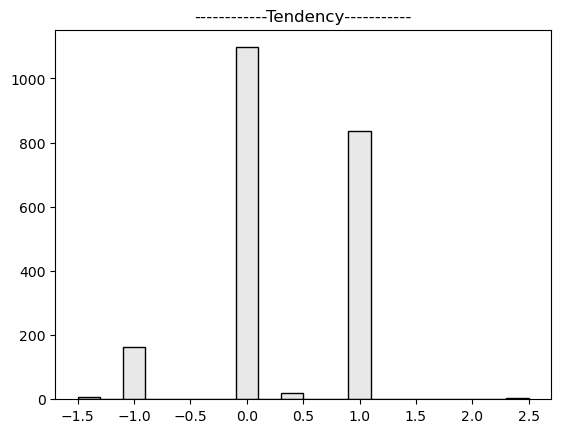

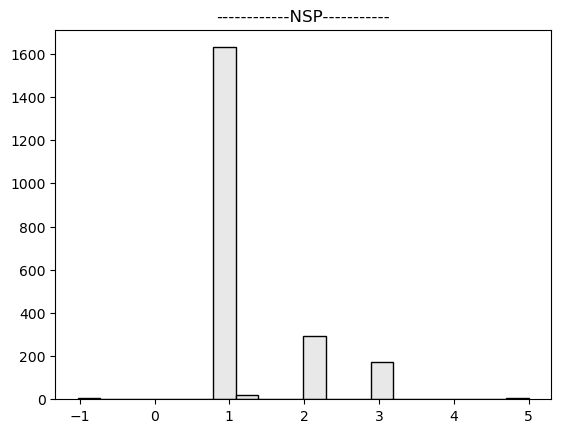

In [12]:
# Plotting histograms to understand the distribution of data
import seaborn as sns
for i in cardiotocographic.select_dtypes(include="number").columns:
    plt.figure()
    plt.title(f"------------{i}-----------")
    plt.hist(cardiotocographic[i],bins=20,
        color='#E8E8E8',
        edgecolor='k')
    if i=="DS":
        plt.xticks(rotation=15)
    plt.show()
    

In [13]:
# Plotting Heatmap to find co-relations 

heat = cardiotocographic.select_dtypes(include="number").corr()
heat

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.080880,-0.006904,-0.162773,-0.156224,-0.006036,-0.052834,0.285623,-0.295485,0.322315,-0.042613,-0.140044,0.281012,0.147396
AC,-0.080880,1.000000,0.076151,0.093970,-0.102722,-0.037528,-0.086556,-0.272436,0.217447,-0.409592,-0.152335,0.283773,0.029403,-0.350042
FM,-0.006904,0.076151,1.000000,-0.317265,-0.017610,0.003393,0.056084,0.156351,0.070300,-0.013420,-0.036875,0.164648,0.000980,0.070732
UC,-0.162773,0.093970,-0.317265,1.000000,0.268605,-0.007533,0.075321,-0.215984,0.297843,-0.293340,-0.074002,0.131802,-0.073700,-0.201739
DL,-0.156224,-0.102722,-0.017610,0.268605,1.000000,0.061076,0.178924,-0.111624,0.566340,-0.295886,-0.242556,0.514648,0.014969,0.013219
DS,-0.006036,-0.037528,0.003393,-0.007533,0.061076,1.000000,0.004285,0.009058,0.025488,-0.008881,-0.004472,0.044130,-0.016015,0.065400
DP,-0.052834,-0.086556,0.056084,0.075321,0.178924,0.004285,1.000000,0.040885,0.176270,-0.112840,-0.179870,0.179659,-0.135873,0.294472
ASTV,0.285623,-0.272436,0.156351,-0.215984,-0.111624,0.009058,0.040885,1.000000,-0.433844,0.439040,-0.324728,-0.241131,-0.009789,0.448072
MSTV,-0.295485,0.217447,0.070300,0.297843,0.566340,0.025488,0.176270,-0.433844,1.000000,-0.541156,0.011692,0.646056,-0.063114,-0.128860
ALTV,0.322315,-0.409592,-0.013420,-0.293340,-0.295886,-0.008881,-0.112840,0.439040,-0.541156,1.000000,-0.133670,-0.439168,0.050845,0.350204


<Axes: >

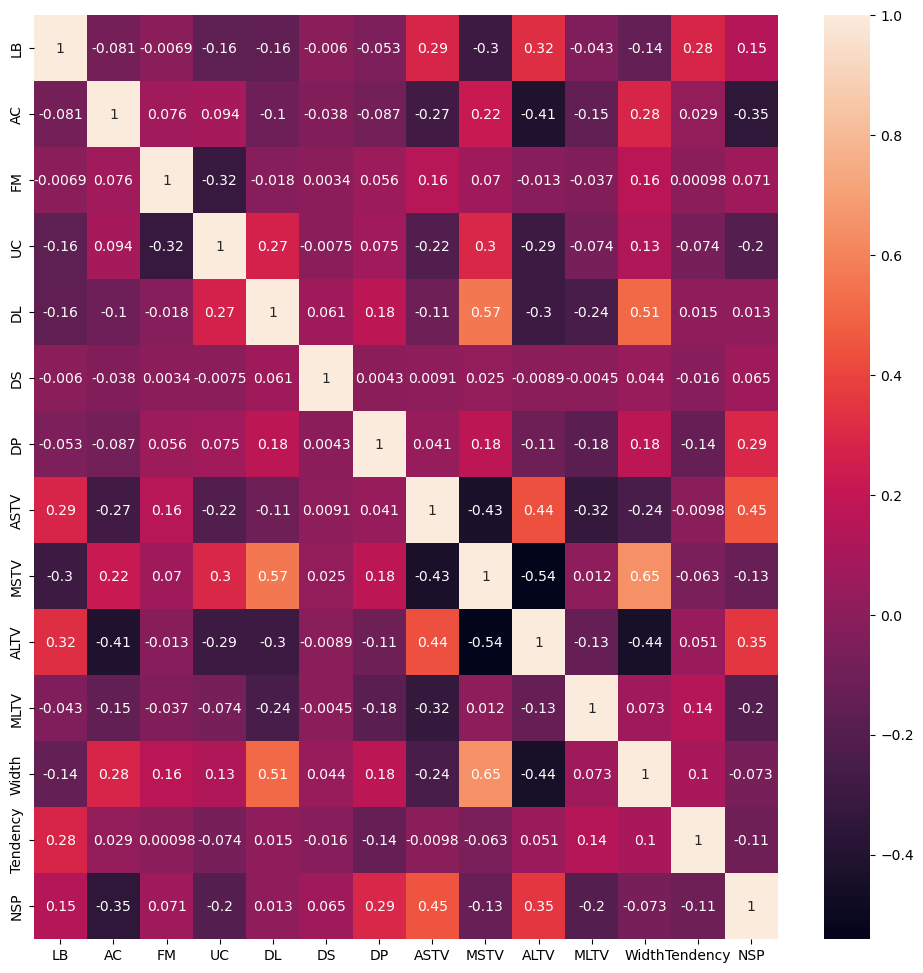

In [14]:
plt.figure(figsize=[12,12])
sns.heatmap(heat, annot=True)

## 4.	Pattern Recognition and Insights:

High Co-relation:-</br>
---  Exist between MSTV <-> width, this could imply Strong relationship: higher variability corresponds to wider distribution of values.</br>
---  Exist between MSTV and DL, this could imply abnormal decelerations in fetal heart rate are associated with variability measures.</br>
---  Exist between ALTV and ASTV, saying  Accelerations and long-term variability are positively related, which makes sense physiologically: more accelerations often accompany higher variability.</br>
---  Strong relationship exist between NSP <->ASTV and NSP <-> ALTV, meaning - normal outcomes are associated with higher accelerations and variability, while abnormal outcomes may show reduced variability.


## 5.	Conclusion:

1. Baseline FHR (LB)
- Mean ~133 bpm, SD ~11 → within normal fetal baseline (110–160 bpm).
- Range: 51–214 bpm → some extreme outliers (likely artifacts or pathological cases).
2. Accelerations (AC) & Fetal Movements (FM)
- AC mean ~0.003 → very low average acceleration count.
- FM mean ~0.009 → also rare.
- Both show skewed distributions (max values much higher than median).
- Suggests accelerations and movements are infrequent in most recordings, but present in some.
3. Uterine Contractions (UC)
- Mean ~0.004 → low frequency overall.
- Max ~0.03 → some cases with stronger contraction activity.
4. Decelerations (DL, DS, DP)
- Means near zero → most cases show no significant decelerations.
- Max values >0.01 → a small subset with pathological decelerations.
- Confirms decelerations are rare but clinically important when present.
5. Variability Measures
- ASTV (Abnormal Short Term Variability): Mean ~47%, wide spread (0–162%).
- Suggests nearly half of monitoring time shows abnormal STV in many cases.
- MSTV (Mean STV): Mean ~1.36 ms, median ~1.2 ms.
- Normal STV should be >6 ms → dataset shows low STV overall, concerning.
- ALTV (Abnormal Long Term Variability): Mean ~10%, but max 182%.
- Indicates some fetuses spend large portions of time with abnormal variability.
- MLTV (Mean LTV): Mean ~8.28 bpm, median ~7.5 bpm.
- Within normal range (6–25 bpm), but wide spread (negative outliers likely artifacts).
6. Other Features
- Width (~70) → reflects histogram width of FHR distribution, large variability.
- Tendency (~0.31) → indicates slight upward trend in FHR baseline.
- NSP (Normal/Pathological/Suspect classification): Mean ~1.3 → most cases classified as “Normal” (1), with smaller proportions of “Suspect” (2) and “Pathological” (3–5).

<b>Key Observation</b>
- Baseline FHR is normal overall, but variability measures (especially STV) are low, suggesting many fetuses in this dataset show reduced autonomic regulation.
- Accelerations and movements are rare, while decelerations are infrequent but clinically significant when present.
- ALTV and ASTV values highlight abnormal variability in a notable subset, consistent with fetal compromise.
- NSP distribution confirms majority are normal, but a meaningful minority are suspect/pathological, making this dataset valuable for classification tasks (e.g., predicting fetal distress).
